In [ ]:
import torch
import numpy as np
import torch.nn.functional as F

from transformers import AutoTokenizer, AutoModel


def add_gumbel_noise(logits, temperature):
    """Add Gumbel noise before taking argmax.

    The implementation keeps the intermediate values in float64 because low-
    precision noise can hurt sampling quality.
    """
    if temperature <= 0:
        return logits

    logits = logits.to(torch.float64)
    noise = torch.rand_like(logits, dtype=torch.float64)
    gumbel_noise = (-torch.log(noise)) ** temperature
    return logits.exp() / gumbel_noise


def get_num_transfer_tokens(mask_index, steps):
    """Precompute how many masked tokens should be revealed at each step.

    The reverse process spreads the total number of masked positions across the
    requested number of sampling steps as evenly as possible.
    """
    mask_num = mask_index.sum(dim=1, keepdim=True)

    base = mask_num // steps
    remainder = mask_num % steps

    num_transfer_tokens = torch.zeros(
        mask_num.size(0), steps, device=mask_index.device, dtype=torch.int64
    ) + base

    for i in range(mask_num.size(0)):
        num_transfer_tokens[i, : int(remainder[i].item())] += 1

    return num_transfer_tokens


@torch.no_grad()
def generate(
    model,
    prompt,
    steps=128,
    gen_length=128,
    block_length=128,
    temperature=0.0,
    cfg_scale=0.0,
    remasking='low_confidence',
    mask_id=126336,
):
    """Generate a continuation with iterative mask prediction.

    The prompt is copied into the left side of the canvas, the remaining slots
    start as masks, and each step fills the most confident masked positions.
    """
    device = next(model.parameters()).device
    prompt_length = prompt.shape[1]
    total_length = prompt_length + gen_length

    x = torch.full((1, total_length), mask_id, dtype=torch.long, device=device)
    x[:, :prompt_length] = prompt.to(device)
    prompt_index = x != mask_id

    assert gen_length % block_length == 0
    num_blocks = gen_length // block_length

    assert steps % num_blocks == 0
    steps = steps // num_blocks

    for num_block in range(num_blocks):
        block_start = prompt_length + num_block * block_length
        block_end = block_start + block_length
        block_mask_index = x[:, block_start:block_end] == mask_id
        num_transfer_tokens = get_num_transfer_tokens(block_mask_index, steps)

        for i in range(steps):
            mask_index = x == mask_id

            # Run either unconditional or classifier-free guided decoding.
            if cfg_scale > 0.0:
                un_x = x.clone()
                un_x[prompt_index] = mask_id
                x_ = torch.cat([x, un_x], dim=0)
                logits = model(x_).logits
                logits, un_logits = torch.chunk(logits, 2, dim=0)
                logits = un_logits + (cfg_scale + 1) * (logits - un_logits)
            else:
                logits = model(x).logits

            # Sample provisional token ids from the current model output.
            logits_with_noise = add_gumbel_noise(logits, temperature=temperature)
            x0 = torch.argmax(logits_with_noise, dim=-1)

            if remasking == 'low_confidence':
                probs = F.softmax(logits.to(torch.float64), dim=-1)
                x0_p = torch.squeeze(
                    torch.gather(probs, dim=-1, index=torch.unsqueeze(x0, -1)), -1
                )
            elif remasking == 'random':
                x0_p = torch.rand((x0.shape[0], x0.shape[1]), device=x0.device)
            else:
                raise NotImplementedError(remasking)

            # Do not reveal tokens beyond the current block.
            x0_p[:, block_end:] = -np.inf

            x0 = torch.where(mask_index, x0, x)
            confidence = torch.where(mask_index, x0_p, -np.inf)

            # Reveal the highest-confidence masked positions for this step.
            transfer_index = torch.zeros_like(x0, dtype=torch.bool, device=x0.device)
            for j in range(confidence.shape[0]):
                _, select_index = torch.topk(confidence[j], k=int(num_transfer_tokens[j, i]))
                transfer_index[j, select_index] = True
            x[transfer_index] = x0[transfer_index]

    return x

In [6]:
model = AutoModel.from_pretrained('GSAI-ML/LLaDA-8B-Instruct', trust_remote_code=True, torch_dtype=torch.bfloat16, device_map="auto")
tokenizer = AutoTokenizer.from_pretrained('GSAI-ML/LLaDA-8B-Instruct', trust_remote_code=True, device_map="auto")
device="cuda"

/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/huggingface_hub/file_download.py:945: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
The model weights are not tied. Please use the `tie_weights` method before using the `infer_auto_device` function.


Loading checkpoint shards:   0%|          | 0/6 [00:00<?, ?it/s]

Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


In [ ]:
@torch.no_grad()
def generate(
    model,
    prompt: torch.Tensor,
    *,
    steps: int = 32,
    gen_length: int = 128,
    block_length: int = 128,
    temperature: float = 0.0,
    cfg_scale: float = 0.0,
    remasking: str = "low_confidence",
    entropy_tau: float = 0.005,
    mask_id: int = 126336,
) -> torch.Tensor:
    """Generate text with an entropy-based early stopping rule.

    Tokens are written first, then the entropy of the remaining masked region is
    checked. If the entropy stops decreasing meaningfully, the loop exits early.
    """
    device = next(model.parameters()).device
    prompt_length = prompt.size(1)

    x = torch.full((1, prompt_length + gen_length), mask_id, dtype=torch.long, device=device)
    x[:, :prompt_length] = prompt.to(device)
    prompt_mask = x != mask_id

    assert gen_length % block_length == 0
    num_blocks = gen_length // block_length
    steps_per_block = steps // max(1, num_blocks)

    for blk in range(num_blocks):
        block_start = prompt_length + blk * block_length
        block_end = block_start + block_length
        block_mask = x[:, block_start:block_end] == mask_id
        num_transfers = get_num_transfer_tokens(block_mask, steps_per_block)

        previous_entropy = None
        for step_idx in range(steps_per_block):
            mask_idx = x == mask_id

            # Score the current canvas, optionally using classifier-free guidance.
            if cfg_scale > 0.0:
                uncond = x.clone()
                uncond[prompt_mask] = mask_id
                logits, un_logits = model(torch.cat([x, uncond])).logits.chunk(2, 0)
                logits = un_logits + (cfg_scale + 1) * (logits - un_logits)
            else:
                logits = model(x).logits

            # Sample a provisional token for every masked position.
            logits_with_noise = add_gumbel_noise(logits, temperature)
            x0 = logits_with_noise.argmax(dim=-1)

            if remasking == "low_confidence":
                probs = torch.softmax(logits.to(torch.float64), dim=-1)
                confidence = probs.gather(-1, x0.unsqueeze(-1)).squeeze(-1)
            elif remasking == "random":
                confidence = torch.rand_like(x0, dtype=torch.float64, device=device)
            else:
                raise ValueError("remasking must be 'low_confidence' or 'random'")

            # Keep the sampler inside the current block.
            confidence[:, block_end:] = -np.inf
            x0 = torch.where(mask_idx, x0, x)
            confidence = torch.where(mask_idx, confidence, -np.inf)

            # Write back only the most confident masked tokens.
            transfer_index = torch.zeros_like(x0, dtype=torch.bool, device=device)
            for batch_idx in range(confidence.size(0)):
                _, selected = confidence[batch_idx].topk(int(num_transfers[batch_idx, step_idx]))
                transfer_index[batch_idx, selected] = True
            x[transfer_index] = x0[transfer_index]

            # Measure entropy over the still-masked region after the update.
            remaining_mask = x == mask_id
            if not remaining_mask.any():
                break

            log_probs = torch.log_softmax(logits[remaining_mask], dim=-1)
            entropy = -(log_probs.exp() * log_probs).sum(-1).mean()

            if previous_entropy is not None and (previous_entropy - entropy) < entropy_tau:
                break
            previous_entropy = entropy

    return x

In [4]:
%%time
q = ("Lily can run 12 kilometers per hour for 4 hours. After that, "
         "she runs 6 kilometers per hour. How many kilometers can she run "
         "in 8 hours?")

chat = [{"role": "user", "content": q}]
prompt_txt = tokenizer.apply_chat_template(chat, add_generation_prompt=True, tokenize=False)
prompt_ids = torch.tensor(tokenizer(prompt_txt).input_ids).unsqueeze(0)

out = generate(model, prompt_ids, steps=128, gen_length=128, block_length=32, temperature=0.0, cfg_scale=0.0)
print(tokenizer.batch_decode(out[:, prompt_ids.size(1):], skip_special_tokens=True)[0])

Lily can 12 kilometers per hour for 4 hours
CPU times: user 378 ms, sys: 283 ms, total: 661 ms
Wall time: 718 ms


In [ ]:
!uv add deepspeed

Will test the following canvas sizes: [64, 128, 256, 512, 1024, 2048, 4096, 6144, 8192, 10240, 12288, 14336, 16384, 18432, 20480, 22528, 24576, 26624, 28672, 30720, 32768, 34816, 36864, 38912]
--- Starting Large-Scale Profiling with DeepSpeed FLOPs Profiler ---

[INFO] Testing with canvas_size = 64...
  > SUCCESS | Total FLOPs: 11428.69 GFLOPs | Peak VRAM: 15653.09 MB

[INFO] Testing with canvas_size = 128...
  > SUCCESS | Total FLOPs: 20105.36 GFLOPs | Peak VRAM: 15869.22 MB

[INFO] Testing with canvas_size = 256...
  > SUCCESS | Total FLOPs: 58607.24 GFLOPs | Peak VRAM: 16301.23 MB

[INFO] Testing with canvas_size = 512...
  > SUCCESS | Total FLOPs: 125318.76 GFLOPs | Peak VRAM: 17165.26 MB

[INFO] Testing with canvas_size = 1024...
  > SUCCESS | Total FLOPs: 199048.47 GFLOPs | Peak VRAM: 18893.31 MB

[INFO] Testing with canvas_size = 2048...
  > SUCCESS | Total FLOPs: 806794.65 GFLOPs | Peak VRAM: 22349.40 MB

[INFO] Testing with canvas_size = 4096...
  > SUCCESS | Total FLOPs: 1653

,Canvas Size,Total FLOPs (GFLOPs),Peak VRAM (MB),Wall Time (s)
0,64,1.142869e+04,15653.092773,0.113330
1,128,2.010536e+04,15869.219238,0.108425
2,256,5.860724e+04,16301.230957,0.141876
3,512,1.253188e+05,17165.256348,0.153978
4,1024,1.990485e+05,18893.305664,0.131676
5,2048,8.067947e+05,22349.404297,0.307986
6,4096,1.653213e+06,29261.601562,0.370866
7,6144,5.063588e+06,36173.798828,0.853668
8,8192,8.597683e+06,43085.996094,1.200911
9,10240,1.312169e+07,49998.194336,1.548266



--- FLOPs Growth Analysis ---
Linear Fit (O(L))      | R-squared: 0.806844
Quadratic Fit (O(L^2))   | R-squared: 0.952926

[CONCLUSION] The data strongly indicates NON-LINEAR, QUADRATIC growth, as expected.


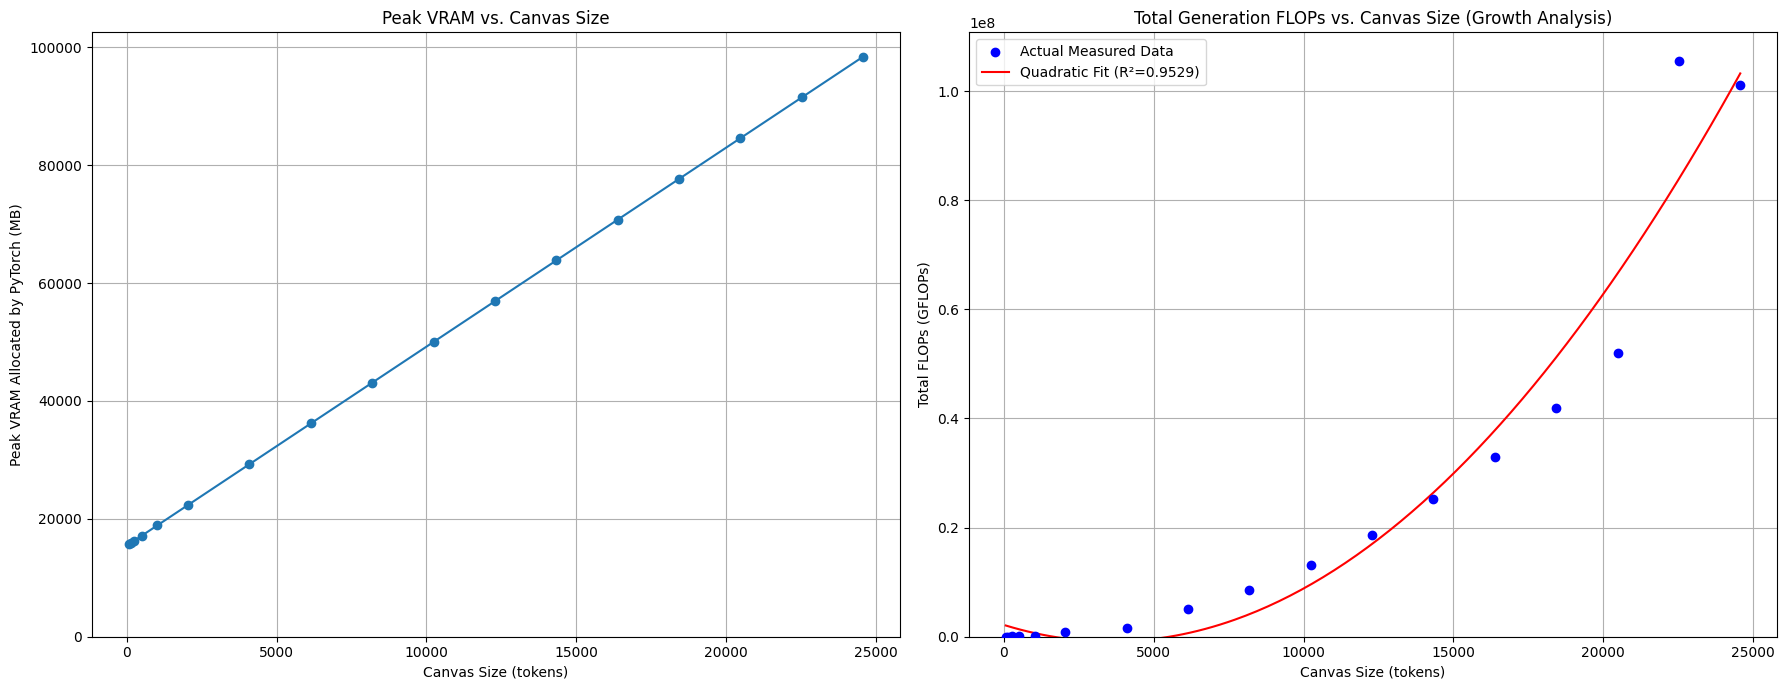

In [ ]:
import torch
import pynvml
import time
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from functools import wraps
from deepspeed.profiling.flops_profiler import FlopsProfiler


# Fit simple growth models to the measured FLOPs data and compare how well they match.
def analyze_and_plot_growth(df):
    """Compare linear and quadratic growth fits for the measured FLOPs."""
    if len(df) < 3:
        print("\n[ANALYSIS] Need at least 3 data points to fit growth curves.")
        return

    print("\n--- FLOPs Growth Analysis ---")

    x = df["Canvas Size"].values
    y = df["Total FLOPs (GFLOPs)"].values

    linear_coeffs = np.polyfit(x, y, 1)
    linear_model = np.poly1d(linear_coeffs)
    linear_y_pred = linear_model(x)

    quad_coeffs = np.polyfit(x, y, 2)
    quad_model = np.poly1d(quad_coeffs)
    quad_y_pred = quad_model(x)

    ss_res_linear = np.sum((y - linear_y_pred) ** 2)
    ss_res_quad = np.sum((y - quad_y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)

    r2_linear = 1 - (ss_res_linear / ss_tot)
    r2_quad = 1 - (ss_res_quad / ss_tot)

    print(f"Linear fit  (O(L))   | R-squared: {r2_linear:.6f}")
    print(f"Quadratic fit (O(L^2)) | R-squared: {r2_quad:.6f}")

    if r2_quad > r2_linear + 0.02:
        print("\n[CONCLUSION] The curve looks closer to quadratic growth in this range.")
    else:
        print("\n[CONCLUSION] The measured range is close to linear growth.")

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

    ax1.plot(df["Canvas Size"], df["Peak VRAM (MB)"], marker="o", linestyle="-")
    ax1.set_title("Peak VRAM vs. Canvas Size")
    ax1.set_xlabel("Canvas Size (tokens)")
    ax1.set_ylabel("Peak VRAM allocated by PyTorch (MB)")
    ax1.grid(True)
    ax1.set_ylim(bottom=0)

    plot_x = np.linspace(min(x), max(x), 200)
    ax2.scatter(x, y, label="Measured data", color="blue", zorder=5)
    ax2.plot(plot_x, quad_model(plot_x), label=f"Quadratic fit (R²={r2_quad:.4f})", color="red")
    ax2.set_title("Total Generation FLOPs vs. Canvas Size")
    ax2.set_xlabel("Canvas Size (tokens)")
    ax2.set_ylabel("Total FLOPs (GFLOPs)")
    ax2.legend()
    ax2.grid(True)
    ax2.set_ylim(bottom=0)

    plt.tight_layout()
    plt.show()


# Measure FLOPs directly with DeepSpeed, then run the model to capture wall time and VRAM.
def profile_generation(func):
    """Profile generation with DeepSpeed FLOPs measurement."""
    @wraps(func)
    def wrapper(canvas_sizes, model, steps, *args, **kwargs):
        results = []
        print("--- Starting profiling with DeepSpeed FLOPs ---")

        for canvas_size in canvas_sizes:
            print(f"\n[INFO] Testing canvas_size = {canvas_size}")
            torch.cuda.synchronize()
            torch.cuda.reset_peak_memory_stats(0)

            try:
                prof = FlopsProfiler(model)
                prof.start_profile()

                start_time = time.time()
                func(gen_length=canvas_size, model=model, steps=steps, *args, **kwargs)
                torch.cuda.synchronize()
                end_time = time.time()

                total_gflops = prof.get_total_flops() / 1e9
                prof.stop_profile()

                peak_vram_allocated = torch.cuda.max_memory_allocated(0) / (1024 ** 2)
                wall_time = end_time - start_time

                print(f"  > Success | Total FLOPs: {total_gflops:.2f} GFLOPs | Peak VRAM: {peak_vram_allocated:.2f} MB")

                results.append({
                    "Canvas Size": canvas_size,
                    "Total FLOPs (GFLOPs)": total_gflops,
                    "Peak VRAM (MB)": peak_vram_allocated,
                    "Wall Time (s)": wall_time,
                })

            except torch.cuda.OutOfMemoryError:
                print(f"  > Failed: OOM at canvas size {canvas_size}. Stopping early.")
                torch.cuda.empty_cache()
                break
            except Exception as exc:
                print(f"  > Failed: unexpected error at canvas size {canvas_size}: {exc}")
                break

        print("\n--- Profiling complete ---")

        if results:
            df = pd.DataFrame(results)
            display(df)
            analyze_and_plot_growth(df)
        else:
            print("No data was successfully collected.")

    return wrapper


@profile_generation
def run_and_profile_generation(gen_length, model, tokenizer, prompt_ids, steps):
    """Run a single generation pass for the requested canvas size."""
    generate(
        model,
        prompt_ids,
        steps=steps,
        gen_length=gen_length,
        block_length=gen_length,
        temperature=0.0,
        cfg_scale=0.0,
    )


# Prepare the prompt once and reuse it for every measurement.
q = "Describe the process of photosynthesis in detail for a high school biology class."
chat = [{"role": "user", "content": q}]
prompt_txt = tokenizer.apply_chat_template(chat, add_generation_prompt=True, tokenize=False)
prompt_ids = torch.tensor(tokenizer(prompt_txt).input_ids).unsqueeze(0).to(model.device)

# Use a compact test range so the notebook stays practical to run.
CANVAS_SIZES_TO_TEST = [64, 128, 256, 512, 1024, 2048, 4096]
print(f"Will test the following canvas sizes: {CANVAS_SIZES_TO_TEST}")

run_and_profile_generation(
    canvas_sizes=CANVAS_SIZES_TO_TEST,
    model=model,
    tokenizer=tokenizer,
    prompt_ids=prompt_ids,
    steps=128,
)

In [ ]:
import torch
import pandas as pd
from functools import wraps
from deepspeed.profiling.flops_profiler import FlopsProfiler
import pynvml
import time
from collections import Counter

# EXPERIMENT A (baseline, raw predictor lengths)
# Input file: predicted_lengths.csv
# Use this block as the no-fallback baseline.
# Measurement model: profile each UNIQUE length once, then scale by frequency.
def profile_generation_with_summation(func):
    """Profile each unique generation length once and aggregate the totals."""
    @wraps(func)
    def wrapper(output_lengths, model, tokenizer, prompt_ids, steps, *args, **kwargs):
        total_flops_sum = 0
        total_gpu_kernel_time_sum = 0

        length_counts = Counter(output_lengths)
        unique_lengths = sorted(length_counts.keys())

        print("--- Starting optimized profiling ---")
        print(f"Found {len(unique_lengths)} unique lengths across {len(output_lengths)} total runs.")

        for i, length in enumerate(unique_lengths):
            count = length_counts[length]
            print(f"\n[INFO] Run {i + 1}/{len(unique_lengths)}: length={length} (repeated {count} times)")

            prof = FlopsProfiler(model)
            prof.start_profile()
            func(gen_length=length, model=model, tokenizer=tokenizer, prompt_ids=prompt_ids, steps=steps, *args, **kwargs)
            flops_for_one_run = prof.get_total_flops()
            prof.stop_profile()

            total_flops_for_this_length = flops_for_one_run * count
            total_flops_sum += total_flops_for_this_length

            print(f"  > FLOPs for one run: {flops_for_one_run / 1e9:.2f} GFLOPs")
            print(f"  > Scaled FLOPs for {count} runs: {total_flops_for_this_length / 1e9:.2f} GFLOPs")

            with torch.profiler.profile(activities=[torch.profiler.ProfilerActivity.CUDA]) as profiler:
                func(gen_length=length, model=model, tokenizer=tokenizer, prompt_ids=prompt_ids, steps=steps, *args, **kwargs)
                torch.cuda.synchronize()

            gpu_time_for_one_run_ns = sum(event.device_time for event in profiler.events())
            total_gpu_time_for_this_length_ns = gpu_time_for_one_run_ns * count
            total_gpu_kernel_time_sum += total_gpu_time_for_this_length_ns

            print(f"  > GPU kernel time for one run: {gpu_time_for_one_run_ns / 1e6:.2f} ms")
            print(f"  > Scaled GPU time for {count} runs: {total_gpu_time_for_this_length_ns / 1e6:.2f} ms")

        print("\n--- Profiling complete ---")
        print(f"\n✅ Total accumulated FLOPs (DeepSpeed): {total_flops_sum / 1e9:.2f} GFLOPs")
        print(f"✅ Total accumulated GPU kernel time: {total_gpu_kernel_time_sum / 1e6:.2f} ms")

        return total_flops_sum, total_gpu_kernel_time_sum

    return wrapper


@profile_generation_with_summation
def run_and_profile(gen_length, model, tokenizer, prompt_ids, steps):
    """Run generation for a single length; the wrapper handles aggregation."""
    generate(
        model=model,
        prompt=prompt_ids,
        steps=steps,
        gen_length=gen_length,
        block_length=gen_length,
    )


# Baseline dataset without fallback adjustment.
try:
    csv_filename = 'predicted_lengths.csv'
    output_lengths_df = pd.read_csv(csv_filename)
    output_lengths_from_csv = output_lengths_df.iloc[:, 0].astype(int).tolist()
    print(f"Loaded {len(output_lengths_from_csv)} output lengths from '{csv_filename}'")
except FileNotFoundError:
    print(f"Error: The file '{csv_filename}' was not found.")
    print("Please run the first code block in the other notebook to generate it.")
    output_lengths_from_csv = []

q = (
    "Lily can run 12 kilometers per hour for 4 hours. After that, "
    "she runs 6 kilometers per hour. How many kilometers can she run "
    "in 8 hours?"
)
chat = [{"role": "user", "content": q}]
prompt_txt = tokenizer.apply_chat_template(chat, add_generation_prompt=True, tokenize=False)
prompt_ids = torch.tensor(tokenizer(prompt_txt).input_ids).unsqueeze(0).to(model.device)

if output_lengths_from_csv:
    total_flops, total_gpu_time = run_and_profile(
        output_lengths=output_lengths_from_csv,
        model=model,
        tokenizer=tokenizer,
        prompt_ids=prompt_ids,
        steps=128,
    )

Loaded 8027 total runs from 'predicted_lengths_with_fallback.csv'
--- Starting Optimized Profiling ---
Found 362 unique lengths to profile out of 8027 total runs.

[INFO] Run 1/362: Profiling for output length = 11 (will be run x2 times)
  > FLOPs for one run: 13539.40 GFLOPs
  > Scaled FLOPs for 2 runs: 27078.80 GFLOPs
  > GPU Kernel Time for one run: 0.04 ms
  > Scaled GPU Time for 2 runs: 0.08 ms

[INFO] Run 2/362: Profiling for output length = 12 (will be run x9 times)
  > FLOPs for one run: 10410.24 GFLOPs
  > Scaled FLOPs for 9 runs: 93692.16 GFLOPs
  > GPU Kernel Time for one run: 0.03 ms
  > Scaled GPU Time for 9 runs: 0.27 ms

[INFO] Run 3/362: Profiling for output length = 13 (will be run x189 times)
  > FLOPs for one run: 10668.96 GFLOPs
  > Scaled FLOPs for 189 runs: 2016433.12 GFLOPs
  > GPU Kernel Time for one run: 0.03 ms
  > Scaled GPU Time for 189 runs: 5.72 ms

[INFO] Run 4/362: Profiling for output length = 14 (will be run x137 times)
  > FLOPs for one run: 10930.72 

In [ ]:
import torch
import pandas as pd
from functools import wraps
from deepspeed.profiling.flops_profiler import FlopsProfiler
import pynvml
import time
from collections import Counter

# EXPERIMENT B (fallback-adjusted predictor lengths)
# Input file: predicted_lengths_fallback.csv
# Use this block for compatibility with the earlier fallback export.
# Measurement model: profile each UNIQUE length once, then scale by frequency.
def profile_generation_with_summation(func):
    """Profile each unique generation length once and scale by frequency."""
    @wraps(func)
    def wrapper(output_lengths, model, tokenizer, prompt_ids, steps, *args, **kwargs):
        total_flops_sum = 0
        total_gpu_kernel_time_sum = 0

        length_counts = Counter(output_lengths)
        unique_lengths = sorted(length_counts.keys())

        print("--- Starting optimized profiling ---")
        print(f"Found {len(unique_lengths)} unique lengths across {len(output_lengths)} total runs.")

        for i, length in enumerate(unique_lengths):
            count = length_counts[length]
            print(f"\n[INFO] Run {i + 1}/{len(unique_lengths)}: length={length} (repeated {count} times)")

            prof = FlopsProfiler(model)
            prof.start_profile()
            func(gen_length=length, model=model, tokenizer=tokenizer, prompt_ids=prompt_ids, steps=steps, *args, **kwargs)
            flops_for_one_run = prof.get_total_flops()
            prof.stop_profile()

            total_flops_for_this_length = flops_for_one_run * count
            total_flops_sum += total_flops_for_this_length

            print(f"  > FLOPs for one run: {flops_for_one_run / 1e9:.2f} GFLOPs")
            print(f"  > Scaled FLOPs for {count} runs: {total_flops_for_this_length / 1e9:.2f} GFLOPs")

            with torch.profiler.profile(activities=[torch.profiler.ProfilerActivity.CUDA]) as profiler:
                func(gen_length=length, model=model, tokenizer=tokenizer, prompt_ids=prompt_ids, steps=steps, *args, **kwargs)
                torch.cuda.synchronize()

            gpu_time_for_one_run_ns = sum(event.device_time for event in profiler.events())
            total_gpu_time_for_this_length_ns = gpu_time_for_one_run_ns * count
            total_gpu_kernel_time_sum += total_gpu_time_for_this_length_ns

            print(f"  > GPU kernel time for one run: {gpu_time_for_one_run_ns / 1e6:.2f} ms")
            print(f"  > Scaled GPU time for {count} runs: {total_gpu_time_for_this_length_ns / 1e6:.2f} ms")

        print("\n--- Profiling complete ---")
        print(f"\n✅ Total accumulated FLOPs (DeepSpeed): {total_flops_sum / 1e9:.2f} GFLOPs")
        print(f"✅ Total accumulated GPU kernel time: {total_gpu_kernel_time_sum / 1e6:.2f} ms")

        return total_flops_sum, total_gpu_kernel_time_sum

    return wrapper


@profile_generation_with_summation
def run_and_profile(gen_length, model, tokenizer, prompt_ids, steps):
    """Run generation for a single length; the wrapper handles aggregation."""
    generate(
        model=model,
        prompt=prompt_ids,
        steps=steps,
        gen_length=gen_length,
        block_length=gen_length,
    )


# Legacy fallback dataset (older export naming).
try:
    csv_filename = 'predicted_lengths_fallback.csv'
    output_lengths_df = pd.read_csv(csv_filename)
    output_lengths_from_csv = output_lengths_df.iloc[:, 0].astype(int).tolist()
    print(f"Loaded {len(output_lengths_from_csv)} total runs from '{csv_filename}'")
except FileNotFoundError:
    print(f"Error: The file '{csv_filename}' was not found.")
    print("Please run the corresponding block in the other notebook to generate it.")
    output_lengths_from_csv = []

q = (
    "Lily can run 12 kilometers per hour for 4 hours. After that, "
    "she runs 6 kilometers per hour. How many kilometers can she run "
    "in 8 hours?"
)
chat = [{"role": "user", "content": q}]
prompt_txt = tokenizer.apply_chat_template(chat, add_generation_prompt=True, tokenize=False)
prompt_ids = torch.tensor(tokenizer(prompt_txt).input_ids).unsqueeze(0).to(model.device)

if output_lengths_from_csv:
    total_flops, total_gpu_time = run_and_profile(
        output_lengths=output_lengths_from_csv,
        model=model,
        tokenizer=tokenizer,
        prompt_ids=prompt_ids,
        steps=128,
    )

In [ ]:
import torch
import pandas as pd
from functools import wraps
from deepspeed.profiling.flops_profiler import FlopsProfiler
import pynvml
import time
from collections import Counter

# EXPERIMENT C (fixed)
# Input file: predicted_lengths_fixed.csv
# Use this to generate the results of a fixed length setup.
# Measurement model: profile each UNIQUE length once, then scale by frequency.
def profile_generation_with_summation(func):
    """Profile each unique generation length once and scale by frequency."""
    @wraps(func)
    def wrapper(output_lengths, model, tokenizer, prompt_ids, steps, *args, **kwargs):
        total_flops_sum = 0
        total_gpu_kernel_time_sum = 0

        length_counts = Counter(output_lengths)
        unique_lengths = sorted(length_counts.keys())

        print("--- Starting optimized profiling ---")
        print(f"Found {len(unique_lengths)} unique lengths across {len(output_lengths)} total runs.")

        for i, length in enumerate(unique_lengths):
            count = length_counts[length]
            print(f"\n[INFO] Run {i + 1}/{len(unique_lengths)}: length={length} (repeated {count} times)")

            prof = FlopsProfiler(model)
            prof.start_profile()
            func(gen_length=length, model=model, tokenizer=tokenizer, prompt_ids=prompt_ids, steps=steps, *args, **kwargs)
            flops_for_one_run = prof.get_total_flops()
            prof.stop_profile()

            total_flops_for_this_length = flops_for_one_run * count
            total_flops_sum += total_flops_for_this_length

            print(f"  > FLOPs for one run: {flops_for_one_run / 1e9:.2f} GFLOPs")
            print(f"  > Scaled FLOPs for {count} runs: {total_flops_for_this_length / 1e9:.2f} GFLOPs")

            with torch.profiler.profile(activities=[torch.profiler.ProfilerActivity.CUDA]) as profiler:
                func(gen_length=length, model=model, tokenizer=tokenizer, prompt_ids=prompt_ids, steps=steps, *args, **kwargs)
                torch.cuda.synchronize()

            gpu_time_for_one_run_ns = sum(event.device_time for event in profiler.events())
            total_gpu_time_for_this_length_ns = gpu_time_for_one_run_ns * count
            total_gpu_kernel_time_sum += total_gpu_time_for_this_length_ns

            print(f"  > GPU kernel time for one run: {gpu_time_for_one_run_ns / 1e6:.2f} ms")
            print(f"  > Scaled GPU time for {count} runs: {total_gpu_time_for_this_length_ns / 1e6:.2f} ms")

        print("\n--- Profiling complete ---")
        print(f"\n✅ Total accumulated FLOPs (DeepSpeed): {total_flops_sum / 1e9:.2f} GFLOPs")
        print(f"✅ Total accumulated GPU kernel time: {total_gpu_kernel_time_sum / 1e6:.2f} ms")

        return total_flops_sum, total_gpu_kernel_time_sum

    return wrapper


@profile_generation_with_summation
def run_and_profile(gen_length, model, tokenizer, prompt_ids, steps):
    """Run generation for a single length; the wrapper handles aggregation."""
    generate(
        model=model,
        prompt=prompt_ids,
        steps=steps,
        gen_length=gen_length,
        block_length=gen_length,
    )


# Current fallback dataset after fixing/cleanup.
try:
    csv_filename = 'predicted_lengths_fixed.csv'
    output_lengths_df = pd.read_csv(csv_filename)
    output_lengths_from_csv = output_lengths_df.iloc[:, 0].astype(int).tolist()
    print(f"Loaded {len(output_lengths_from_csv)} total runs from '{csv_filename}'")
except FileNotFoundError:
    print(f"Error: The file '{csv_filename}' was not found.")
    print("Please run the corresponding block in the other notebook to generate it.")
    output_lengths_from_csv = []

q = (
    "Lily can run 12 kilometers per hour for 4 hours. After that, "
    "she runs 6 kilometers per hour. How many kilometers can she run "
    "in 8 hours?"
)
chat = [{"role": "user", "content": q}]
prompt_txt = tokenizer.apply_chat_template(chat, add_generation_prompt=True, tokenize=False)
prompt_ids = torch.tensor(tokenizer(prompt_txt).input_ids).unsqueeze(0).to(model.device)

if output_lengths_from_csv:
    total_flops, total_gpu_time = run_and_profile(
        output_lengths=output_lengths_from_csv,
        model=model,
        tokenizer=tokenizer,
        prompt_ids=prompt_ids,
        steps=128,
    )

Loaded 7999 total runs from 'predicted_lengths_doubling_fallback.csv'
--- Starting Optimized Profiling ---
Found 1 unique lengths to profile out of 7999 total runs.

[INFO] Run 1/1: Profiling for output length = 4096 (will be run x7999 times)
  > FLOPs for one run: 22335756.03 GFLOPs
  > Scaled FLOPs for 7999 runs: 178663712518.97 GFLOPs
  > GPU Kernel Time for one run: 0.33 ms
  > Scaled GPU Time for 7999 runs: 2657.46 ms

--- Profiling Complete ---

✅ Total Accumulated FLOPs (DeepSpeed): 178663712518.97 GFLOPs
✅ Total Accumulated GPU Kernel Time (Nvidia): 2657.46 ms
